### Define the libaries

In [1]:
using DifferentialEquations
using LinearAlgebra
using NPZ
using ProgressBars
using ProgressMeter
using Integrals
using Plots

### Define steady state of the CNT without the interaction term

In [2]:
const fm=289

const nu=1.15e-3
const beta=1.5e-07
const xscale=4 

## re-scale for equation of motion
const epsilon=beta/(xscale)^2
const delta=nu/1.5

print(epsilon)
print('\n')
print(delta)

const w0=fm*2*pi

## range of frequency to sweep = same as python code
# nomralized with w0
const w1=280*2*pi/w0
const w2=305*2*pi/w0

# Frequency Points
f1 = LinRange(w1,w2,200) # driving frequency sweep

### Import solution for initial conditions in the duffing regime
Inital_cond_up=npzread("InitialConditions/InitialConditions_up.npz")
Inital_cond_down=npzread("InitialConditions/InitialConditions_down.npz")
sweep_up=Inital_cond_up["duffing_sweep_up"];
sweep_down=Inital_cond_down["duffing_sweep_down"];

9.375e-9
0.0007666666666666667

### Solve the equation of motion using ODEProblem for various values of forces

In [5]:
F_values=[xscale/2.5,xscale/5,xscale/50]
##selection of 3 values of forces corresponding to each regime of driving 
print(F_values)

steady_state_up_F=zeros(length(f1),length(F_values))
steady_state_down_F=zeros(length(f1),length(F_values)) 

@showprogress for f in eachindex(1:length(F_values))
        F0=F_values[f]
        for point in eachindex(1:length(f1))
            ### define the frequency to evaluate
            omega=f1[point]
            tspan = (0,5000*pi/omega) 
            function duffing_eqn_ODE(du, u, p, t)
                du[1] = u[2]
                du[2] = - delta * u[2] -  u[1] - epsilon * u[1]^3 + F0* cos(omega * t) 
            end
            ### solve the ODE problem
            ## up sweep
            u0_up = [sweep_up[point]; 0]
            prob_up = ODEProblem(duffing_eqn_ODE, u0_up, tspan)
            sol_up = solve(prob_up, Vern9(),dt=1e-10,abstol=1e-5,reltol=1e-5)

            ## down sweep
            u0_down = [0;0]
            prob_down = ODEProblem(duffing_eqn_ODE, u0_down, tspan)
            sol_down = solve(prob_down, Vern9(),dt=1e-10,abstol=1e-5,reltol=1e-5)#, adaptive = false)


            ### calcualte the maximun such that average*e^{i*omega*t}
            start=800
            average_up=maximum(sol_up[1,end-30:end])
            average_down=maximum(sol_down[1,end-30:end])

            ### save
            steady_state_up_F[point,f]=average_up
            steady_state_down_F[point,f]=average_down
        end

end

dicctionary=Dict("freq" => f1,
"Initial_cond" =>sweep_up, 
"F1.6_up" =>steady_state_up_F[:,1],
"F0.8_up" =>steady_state_up_F[:,2], 
"F0.08_up" =>steady_state_up_F[:,3],
"F1.6_down" =>steady_state_down_F[:,1],
"F0.8_down" =>steady_state_down_F[:,2], 
"F0.08_down" =>steady_state_down_F[:,3])
npzwrite("Simulations/Example_initial_cond.npz", dicctionary)

[1.6, 0.8, 0.08]

Progress: 100%|█████████████████████████████████████████| Time: 0:00:12


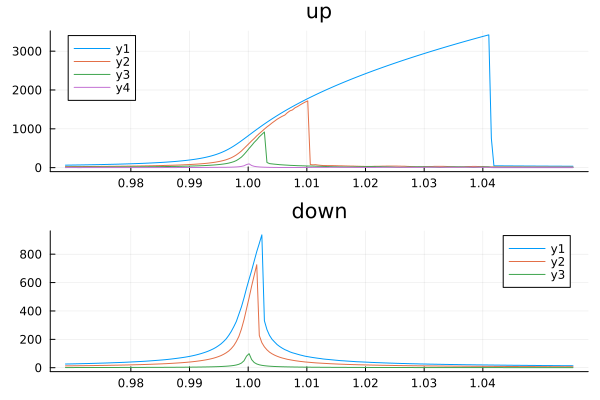

In [6]:
### plot the results
p1 = plot(f1,[sweep_up,steady_state_up_F[:,1],steady_state_up_F[:,2],steady_state_up_F[:,3]],title="up")
p2= plot(f1,[steady_state_down_F[:,1],steady_state_down_F[:,2],steady_state_down_F[:,3]],title="down")

plot(p1,p2,layout=(2,1),xticks = 0.98:.01:1.04)

### Incorporate the back action of the electron transport

-0.1
0.1
3.0

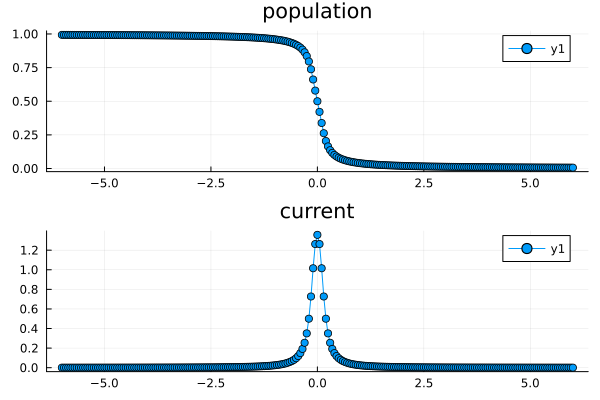

In [5]:
#### tunneling parameters

const e = 1.602e-19             # elementary charge
const h = 6.62606957e-34/(2*pi) # \hbar in Js 
const hbar=h/e ## in eV s

const Vb= .2 # gate bias of the arches  (mV)

const muR = - Vb /2    # right chemical potential (meV)
const muL = Vb/2   # left chemical potential (meV)
print(muR)
print('\n')
print(muL)
print('\n')
###################### parameters from the coulomb peak
const GL=  30*2*pi*1e9 ## in (Hz)
const GR= 30*2*pi*1e9 ## in (Hz)
const gm= 3*(w0*1e6) ## in (Hz)

const a=GL/GR ## unitless
const Gtot = (GL + GR) ## in (Hz)
const hGtot_meV = h/e*(GL + GR)*1e3## in meV
const g_fm=gm/(w0*1e6)
print(g_fm)
######################

mu0_range=range(-6,6,step=0.05) ## in meV


function population(mu0)
    p= 0.5+ GR/(pi*Gtot)*(atan(2*(muR-mu0)/hGtot_meV)+a*atan(2*(muL-mu0)/hGtot_meV))
    
end

function current(mu0)
    I=atan(2*(muL-mu0)/hGtot_meV)-atan(2*(muR-mu0)/hGtot_meV)
end


p1=plot(mu0_range,population.(mu0_range),marker=:circle,title="population")
p2=plot(mu0_range,current.(mu0_range),marker=:circle,title="current")
plot(p1,p2, layout=(2,1))

### Obtain the steady state displacement over a sweep of mu0 and driving frequencies

In [ ]:

for f in eachindex(1:length(F_values))
    F0=F_values[f]
    ## create empty arrays to save the steady state amplitude
    ultrastrong_sweep_up=zeros(length(f1),length(mu0_range))
    ultrastrong_sweep_down=zeros(length(f1),length(mu0_range))

    ultrastrong_current_up=zeros(length(f1),length(mu0_range))
    ultrastrong_current_down=zeros(length(f1),length(mu0_range))

    @showprogress for point in eachindex(1:length(f1))
        ## define the value of frequency
        omega=f1[point]
        tspan = (0,5000*pi/omega) 
        for j in 1:length(mu0_range)
            ## define the gate voltage
            mu0=mu0_range[j]

            ### solve ODE
            #################################
            function ultrastrong_ODE(du,u,p,t)
                    μ = mu0 + gm*hbar*1e3*u[1] ## in meV
                    pop= 0.5 + (atan(2*(muR - μ)/hGtot_meV) + a*atan(2*(muL - μ)/hGtot_meV))/(pi*(1 + a))

                    # diferential equation
                    du[1] = u[2]
                    du[2] = - delta * u[2] - (u[1]+2*g_fm*pop)- epsilon * u[1]^3 + F0* cos(omega * t)
                end
        #################################
            ## up sweep
            u0_up = [sweep_up[point]; 0]
            prob_up = ODEProblem(ultrastrong_ODE, u0_up, tspan)
            sol_up = solve(prob_up, Vern9(),dt=1e-10,abstol=1e-5,reltol=1e-5)

            ## down sweep
            u0_down = [0; 0]
            prob_down = ODEProblem(ultrastrong_ODE, u0_down, tspan)
            sol_down = solve(prob_down, Vern9(),dt=1e-10,abstol=1e-5,reltol=1e-5)

            ### calucalte the average
            average_up= maximum(sol_up[1,end-30:end])
            average_down= maximum(sol_down[1,end-30:end])

            ### save the results
            ultrastrong_sweep_up[point,j]=average_up
            ultrastrong_sweep_down[point,j]=average_down

            ### compute the current
            ### up sweep function
            function I_up(t,p)
                mu = mu0 + gm*hbar*1e3*cos(t*omega)*average_up
                I=atan(2*(muL-mu)/hGtot_meV)-atan(2*(muR-mu)/hGtot_meV)
            end
            domain = (0, 4*pi/omega) 
            prob_up = IntegralProblem(I_up, domain)
            sol_up = solve(prob_up, QuadGKJL())

            #### same function as before but used for the down sweep
            function I_down(t,p)
                mu = mu0 + gm*hbar*1e3*cos(t*omega)*average_down
                I=atan(2*(muL-mu)/hGtot_meV)-atan(2*(muR-mu)/hGtot_meV)
            end
            prob_down = IntegralProblem(I_down, domain)
            sol_down = solve(prob_down, QuadGKJL())

            # ### save the results
            ultrastrong_current_up[point,j]=sol_up.u/(4*pi/omega) 
            ultrastrong_current_down[point,j]=sol_down.u/(4*pi/omega) 
        end
    end
    
    
    ### save each file containing all the data
    dicctionary=Dict("mu" => mu0_range, "fm" =>f1,
    "bare_displacement_up" =>steady_state_up_F[:,f], 
    "bare_displacement_down" =>steady_state_down_F[:,f], 
    "displacement_up" =>ultrastrong_sweep_up, 
    "displacement_down" =>ultrastrong_sweep_down,
    "current_up" =>ultrastrong_current_up, 
    "current_down" =>ultrastrong_current_down)
    npzwrite("Simulations/Displacement_CNT_theory_F_"*string(F0)*".npz", dicctionary)
end
    

### Numerical details for obtaining the NESS --> Included in Appendix B

In [9]:
@showprogress for f in eachindex(1:length(F_values))
    F0=F_values[f]
    omega=f1[100] # roughly omega=1
    mu0=0
    tspan = (0,5000*pi/omega) 
    function ultrastrong_ODE(du,u,p,t)
            μ = mu0 + gm*hbar*1e3*u[1]
            pop= 0.5 + (atan(2*(muR - μ)/hGtot_meV) + a*atan(2*(muL - μ)/hGtot_meV))/(pi*(1 + a))

            # diferential equation
            du[1] = u[2]
            du[2] = - delta * u[2] - (u[1]+2*g_fm*pop)- epsilon * u[1]^3 + F0* cos(omega * t)
        end
        u0_up = [sweep_up[100]; 0]
        prob_up = ODEProblem(ultrastrong_ODE, u0_up, tspan)
        sol_up = solve(prob_up, Vern9(),dt=1e-10,abstol=1e-5,reltol=1e-5)

        ## down sweep
        u0_down = [0; 0]
        prob_down = ODEProblem(ultrastrong_ODE, u0_down, tspan)
        sol_down = solve(prob_down, Vern9(),dt=1e-10,abstol=1e-5,reltol=1e-5)
    
        ### save each file containing all the data
        dicctionary=Dict("mu" => mu0, "fm" =>omega,
        "displacement_up" =>sol_up[1,:], 
        "displacement_down" =>sol_down[1,:])
        npzwrite("Simulations/time_dynamics_displacement_backaction_"*string(F0)*".npz", dicctionary)
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
